# Adaptive Media Processing Assignment 2

## Fisher’s Iris Classification Problem
This is a classical benchmark problem in pattern recognition which asks to classify the 3 species of
plants (iris) from the characteristics observed in their flowers.
Reference : Fisher, R.A. (1936). "The Use of Multiple Measurements in Taxonomic Problems". Annals of Eugenics 7:
179–188.
Classes (3 classes)
1. Iris Setosa 2. Iris Versicolour 3. Iris Virginica

Features

    1. Petal length (cm), 2. Petal width (cm),
    3. Sepal length (cm), 4. Sepal width (cm)

Data
50 examples/class. 150 examples in total.

## Problem
Download the Fisher’s iris data from the Machine Learning Repository at UC Irvine
http://archive.ics.uci.edu/ml/datasets/Iris

In the file “iris.data”, each row represents a measurement from an iris flower. Each row include the 4
features and the species (class).

Divide the data of each class into half. Use one half for training (training set), and the other half for
testing (test set). Build classifiers for this data by the following two methods A and B.

A. k-nearest neighbor classifier.
B. Fisher’s linear discriminator. Prepare 3 classifiers for 2-class problems classifying one class
against the other two. You may also be interested to seek information about the Multi-class Linear
Discriminant Analysis in the literature.

The classifiers should be trained using the training set, and evaluated using the test set. Repeat (1)
random selection of training set, (2) training, and (3) testing for 20 times. Evaluate the mean correct
classification rates and their variances for both methods. Discuss what causes the differences.

You may use the programming language of your choice. Program the core classifier parts by
reviewing the course materials and see if it really works as explained in the lecture. Do not use
ready-made tools (e.g. the “LinearDiscriminantAnalysis” package of scikit-learn). Do not copy-paste
Fisher-LDA programs floating around on the net. This is a must. In the report, include your source
codes.
## Submission
Submit your program and the results in PDF at Manaba by the deadline set at the report page

# Solution

## KNN Classifier

This classifier identifies the `k` nearest neighbors of a given input `X`. It does so by calculating the Euclidean distance between `X` and every sample in the training dataset. Once the nearest neighbors have been selected, each neighbor votes for its corresponding class, and the class with the highest number of votes is returned.

This classifier has two main methods:

* `fit`: Stores all training inputs together with their corresponding labels. No additional parameter estimation is required for KNN.
* `predict`: Retrieves the `k` nearest neighbors for each test sample and returns the class with the highest vote count.

In [21]:
class KNNClassifier:
    """A simple k-nearest neighbors classifier.

    Attributes:
        k (int): Number of nearest neighbors to consider during prediction.
        X_train (list[list[float]]): Training feature vectors.
        y_train (list): Training labels corresponding to each row in X_train.
    """

    def __init__(self, k):
        """Create a new KNN classifier.

        Args:
            k (int): Number of neighbors to use for majority voting.
        """
        self.k = k

    def fit(self, X_train, y_train):
        """Store training data for later predictions.
        It is mainly used to avoid having to pass the training data
        to the predict method every time we want to make a prediction.

        Args:
            X_train (list[list[float]]): Training examples.
            y_train (list): Class labels for the training examples.
        """
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):
        """Predict labels for a collection of test examples.

        Args:
            X_test (list[list[float]]): Test examples to classify.

        Returns:
            list: Predicted labels for each test example.
        """
        predicted_labels = [self._predict(x) for x in X_test]
        return predicted_labels

    def _predict(self, x):
        """Predict the label for a single test example.

        Args:
            x (list[float]): A single example to classify.

        Returns:
            The predicted label chosen by majority vote among the k nearest neighbors.
        """
        distances = [self._euclidean_distance(x, x_train) for x_train in self.X_train]
        k_nearest_neighbors = self._get_distances_with_idx_sorted(distances)
        k_nearest_labels = self._get_nearest_labels(k_nearest_neighbors)
        return self._get_most_voted_label(k_nearest_labels)

    def _get_distances_with_idx_sorted(self, distances):
        """Sort training examples by distance and return the closest k indices.

        Args:
            distances (list[float]): Distance values from a test example to each training example.

        Returns:
            list[tuple[int, float]]: Tuples of (index, distance) for the k closest neighbors.
        """
        distances_with_indices = [(index, distance) for index, distance in enumerate(distances)]
        sorted_distances = sorted(distances_with_indices, key=lambda x: x[1])
        return sorted_distances[:self.k]
    
    def _get_nearest_labels(self, distances_with_idx):
        """Lookup labels for the nearest neighbor indices.

        Args:
            distances_with_idx (list[tuple[int, float]]): Sorted index-distance pairs.

        Returns:
            list: Labels of the k nearest training examples.
        """
        k_nearest_labels = [self.y_train[index] for index, _ in distances_with_idx]
        return k_nearest_labels
    
    def _get_most_voted_label(self, labels):
        """Return the label with the highest vote count.
        This means the label that appears most frequently among the k nearest neighbors.
        

        Args:
            labels (list): Labels from the k nearest neighbors.

        Returns:
            The most common label among the given labels.
        """
        votes = {label: labels.count(label) for label in set(labels)}
        return max(votes, key=votes.get)

    def _euclidean_distance(self, x1, x2):
        """Compute Euclidean distance between two vectors.

        Args:
            x1 (list[float]): First vector.
            x2 (list[float]): Second vector.

        Returns:
            float: Euclidean distance between x1 and x2.
        """
        return sum((a - b) ** 2 for a, b in zip(x1, x2)) ** 0.5

In [22]:
import pandas as pd
from sklearn.datasets import load_iris

# Load as a Scikit-Learn Bunch object
iris = load_iris()

# Convert to a standard Pandas DataFrame for easy analysis
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target  # Add the numeric labels (0, 1, 2)
df['species'] = df['target'].map({i: name for i, name in enumerate(iris.target_names)})

print(df.head())
print(df.info())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             

In [23]:
df_train = df.sample(frac=0.5, random_state=42)  # 80% for training
df_test = df.drop(df_train.index)  # Remaining 20% for testing

In [24]:
knn_classifier = KNNClassifier(k=3)

knn_classifier.fit(df_train[iris.feature_names].values, df_train['target'].values)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        21
  versicolor       0.96      0.89      0.92        27
   virginica       0.90      0.96      0.93        27

    accuracy                           0.95        75
   macro avg       0.95      0.95      0.95        75
weighted avg       0.95      0.95      0.95        75

[[21  0  0]
 [ 0 24  3]
 [ 0  1 26]]


<Axes: >

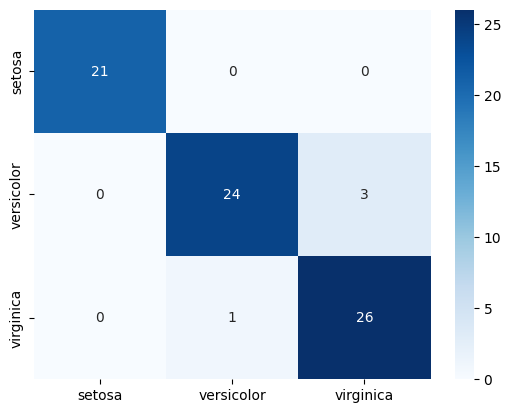

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_knn = knn_classifier.predict(df_test[iris.feature_names].values)
print(classification_report(df_test['target'].values, y_pred_knn, target_names=iris.target_names))
print(confusion_matrix(df_test['target'].values, y_pred_knn))
sns.heatmap(
    confusion_matrix(
        df_test['target'].values,
        y_pred_knn
    ),
    annot=True, 
    fmt='d',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    cmap='Blues'
)

### Best k for this dataset

To select an appropriate value for `k`, which is the main hyperparameter of KNN, the classifier is evaluated using values from 1 to 20.

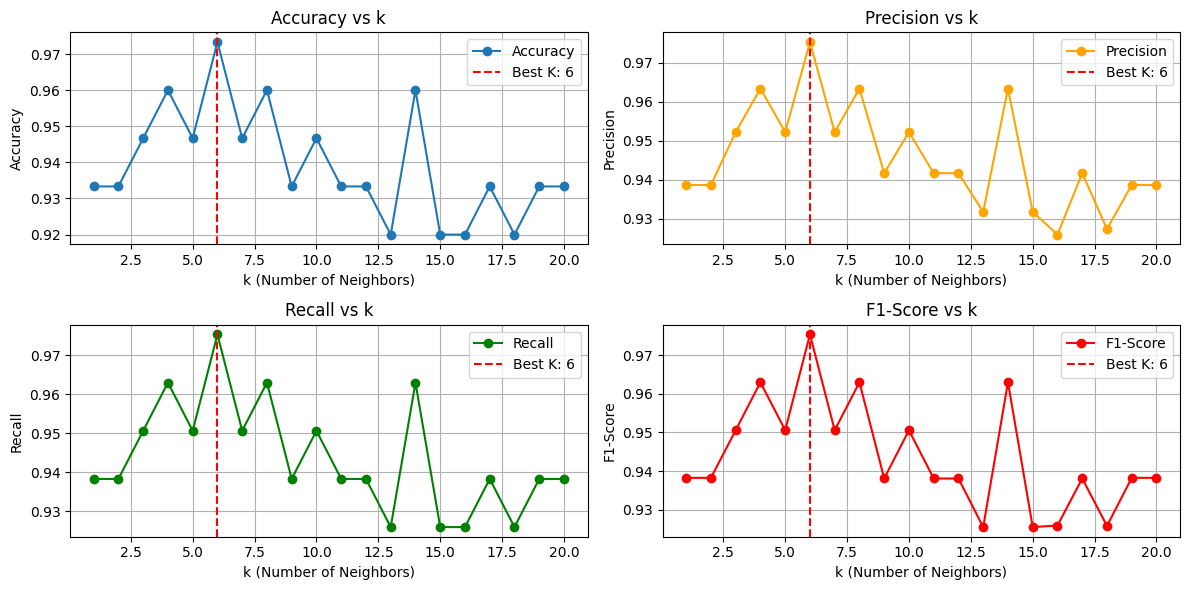

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


k_choices = list(range(1, 21))


results = []

best_k_accuracy = {'k': 0, 'accuracy': 0}
best_k_precision = {'k': 0, 'precision': 0}
best_k_recall = {'k': 0, 'recall': 0}
best_k_f1_score = {'k': 0, 'f1_score': 0}

for choice in k_choices:
    knn_classifier = KNNClassifier(k=choice)
    knn_classifier.fit(df_train[iris.feature_names].values,
                       df_train['target'].values)
    y_pred_knn = knn_classifier.predict(df_test[iris.feature_names].values)
    accuracy = accuracy_score(df_test['target'].values, y_pred_knn)
    precision = precision_score(df_test['target'].values, y_pred_knn, average='macro')
    recall = recall_score(df_test['target'].values, y_pred_knn, average='macro')
    f1 = f1_score(df_test['target'].values, y_pred_knn, average='macro')

    if accuracy > best_k_accuracy['accuracy']:
        best_k_accuracy = {'k': choice, 'accuracy': accuracy}
    if precision > best_k_precision['precision']:
        best_k_precision = {'k': choice, 'precision': precision}
    if recall > best_k_recall['recall']:
        best_k_recall = {'k': choice, 'recall': recall}
    if f1 > best_k_f1_score['f1_score']:
        best_k_f1_score = {'k': choice, 'f1_score': f1}

    results.append((choice, accuracy, precision, recall, f1))

import matplotlib.pyplot as plt

k_values, accuracies, precisions, recalls, f1_scores = zip(*results)
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 6))

axs[0, 0].plot(k_values, accuracies, label='Accuracy', marker='o')
axs[0, 0].axvline(x=best_k_accuracy['k'], color='red', linestyle='--', label=f'Best K: {best_k_accuracy["k"]}')
axs[0, 0].set_xlabel('k (Number of Neighbors)')
axs[0, 0].set_ylabel('Accuracy')
axs[0, 0].set_title('Accuracy vs k')
axs[0, 0].legend()
axs[0, 0].grid()

axs[0, 1].plot(k_values, precisions, label='Precision', marker='o', color='orange')
axs[0, 1].axvline(x=best_k_precision['k'], color='red', linestyle='--', label=f'Best K: {best_k_precision["k"]}')
axs[0, 1].set_xlabel('k (Number of Neighbors)')
axs[0, 1].set_ylabel('Precision')
axs[0, 1].set_title('Precision vs k')
axs[0, 1].legend()
axs[0, 1].grid()

axs[1, 0].plot(k_values, recalls, label='Recall', marker='o', color='green')
axs[1, 0].axvline(x=best_k_recall['k'], color='red', linestyle='--', label=f'Best K: {best_k_recall["k"]}')
axs[1, 0].set_xlabel('k (Number of Neighbors)')
axs[1, 0].set_ylabel('Recall')
axs[1, 0].set_title('Recall vs k')
axs[1, 0].legend()
axs[1, 0].grid()

axs[1, 1].plot(k_values, f1_scores, label='F1-Score', marker='o', color='red')
axs[1, 1].axvline(x=best_k_f1_score['k'], color='red', linestyle='--', label=f'Best K: {best_k_f1_score["k"]}')
axs[1, 1].set_xlabel('k (Number of Neighbors)')
axs[1, 1].set_ylabel('F1-Score')
axs[1, 1].set_title('F1-Score vs k')
axs[1, 1].legend()
axs[1, 1].grid()

plt.tight_layout()
plt.show()

Based on these results, the best value of `k` for this dataset is selected as `k = 6`.

## Fisher Classifier

This classifier is implemented using `n` binary classifiers based on Fisher's linear discriminator. In the Iris dataset, there are three classes: Setosa, Versicolor, and Virginica. Therefore, for this dataset, `n = 3`, and three binary classifiers are created.

These classifiers are then combined using a one-vs-rest approach. To determine which class best corresponds to an input `X`, the input is projected using each Fisher discriminator and compared with the corresponding threshold. Instead of using each threshold only to produce a binary decision, each classifier returns a score that represents how far the projected sample is from its decision boundary. The final predicted class is the one with the highest score.

This classifier has two main methods:

* `fit`: Trains one Fisher binary classifier for each class. It calculates `w`, the weight vector that maximizes class separability, and the threshold used as the decision boundary.
* `predict`: Calculates the score produced by each binary classifier and selects the class whose classifier gives the highest score.

In [27]:
import numpy as np


class FisherBinaryClassifier:
    """A simple Fisher's linear discriminant binary classifier.
    """

    def __init__(self):
        self._fitted = False
        self.w = None
        self.threshold = None

    def fit(self, X_train, y_train):
        """Fit the Fisher's linear discriminant model to the training data.
        It calculates the projection matrix w which maximizes the separation
        between the two classes in the projected space, and also calculates
        the threshold for classification based on the means of the projected classes.

        Args:
            X_train (list[list[float]]): Training feature vectors.
            y_train (list): Training labels corresponding to each row in X_train.
        """
        X0 = X_train[y_train == 0]
        X1 = X_train[y_train == 1]

        # First, compute the means for each class
        mu0 = X0.mean(axis=0)
        mu1 = X1.mean(axis=0)

        # Next, compute the between class scatter matrices for each class
        d0 = (X0 - mu0).reshape(X0.shape[0], -1)
        S0 = d0.T @ d0
        d1 = (X1 - mu1).reshape(X1.shape[0], -1)
        S1 = d1.T @ d1

        # Calculate the total between-class scatter matrix
        SB = S0 + S1

        # Calculate w using the formula w = SB^-1 * (mu1 - mu0)
        self.w = np.linalg.pinv(SB) @ (mu1 - mu0)

        # Calculate the threshold as the midpoint between the projections of the class means onto w
        m0 = self.w @ mu0
        m1 = self.w @ mu1

        self.threshold = (m0 + m1) / 2

        self._fitted = True

    def predict(self, X_test):
        """Predict labels for a collection of test examples.
        Projects the test examples onto the weight vector w and compares
        to the threshold to determine class labels.

        Args:
            X_test (list[list[float]]): Test examples to classify.
        Returns:
            list: Predicted labels for each test example.
        """
        if not self._fitted:
            raise ValueError("The model has not been fitted yet.")

        # Project the test examples onto the weight vector w and compare to the threshold
        scores = X_test @ self.w - self.threshold

        return (scores >= 0).astype(bool)


class FisherClassifier:
    """A simple OvR (One vs Rest) Fisher's linear discriminant classifier.
    This class uses multiple fisher binary classifiers to handle multi-class
    classification problems.
    """

    def __init__(self):
        self._binary_classifiers = []
        self._unique_classes = []
        self._fitted = False

    def fit(self, X_train, y_train):
        """Fit the Fisher's linear discriminant model to the training class with the biggest score is selecteddata.

        Args:
            X_train (list[list[float]]): Training feature vectors.
            y_train (list): Training labels corresponding to each row in X_train.
        """
        unique_classes = np.unique(y_train)
        self._binary_classifiers = []
        self._unique_classes = unique_classes

        for c in unique_classes:
            binary_y_train = (y_train == c).astype(int)
            clf = FisherBinaryClassifier()
            clf.fit(X_train, binary_y_train)
            self._binary_classifiers.append(clf)

        self._fitted = True

    def predict(self, X_test):
        """Predict labels for a collection of test examples.

        Args:
            X_test (list[list[float]]): Test examples to classify.
        Returns:
            list: Predicted labels for each test example.
        """
        if not self._fitted:
            raise ValueError("The model has not been fitted yet.")

        scores = []
        for clf in self._binary_classifiers:
            score = X_test @ clf.w - clf.threshold
            scores.append(score)
        predictions = self._unique_classes[np.argmax(scores, axis=0)]

        return predictions


In [28]:
fisher_classifier = FisherClassifier()

fisher_classifier.fit(df_train[iris.feature_names].values, df_train['target'].values)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        21
  versicolor       0.85      0.85      0.85        27
   virginica       0.85      0.85      0.85        27

    accuracy                           0.89        75
   macro avg       0.90      0.90      0.90        75
weighted avg       0.89      0.89      0.89        75

[[21  0  0]
 [ 0 23  4]
 [ 0  4 23]]


<Axes: >

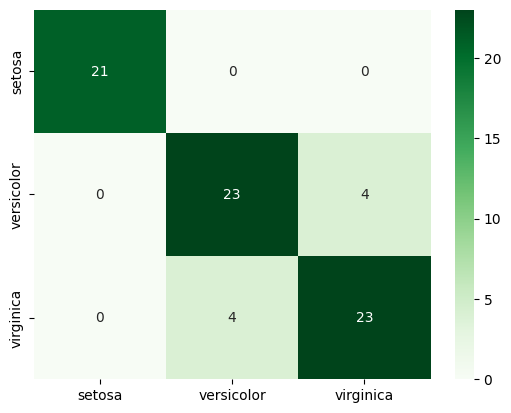

In [29]:
y_pred_fisher = fisher_classifier.predict(df_test[iris.feature_names].values)
print(classification_report(df_test['target'].values, y_pred_fisher, target_names=iris.target_names))
print(confusion_matrix(df_test['target'].values, y_pred_fisher))
sns.heatmap(
    confusion_matrix(
        df_test['target'].values,
        y_pred_fisher
    ),
    annot=True, 
    fmt='d',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    cmap='Greens'
)

## Metrics

In this section, both `KNNClassifier` and `FisherClassifier` are trained and evaluated on the Iris dataset.

In [30]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

X = df[iris.feature_names].values
y = df["target"].values

splitter = StratifiedShuffleSplit(
    n_splits=20,
    test_size=0.5,
    random_state=42
)

metrics_rows = []

for split_number, (train_idx, test_idx) in enumerate(splitter.split(X, y), start=1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    classifiers = {
        "KNN": KNNClassifier(k=6),
        "Fisher": FisherClassifier(),
    }

    for classifier_name, classifier in classifiers.items():
        classifier.fit(X_train, y_train)
        y_pred = np.asarray(classifier.predict(X_test))
        report = classification_report(
            y_test,
            y_pred,
            labels=np.arange(len(iris.target_names)),
            target_names=iris.target_names,
            output_dict=True,
            zero_division=0,
        )

        metrics_rows.append({
            "split": split_number,
            "classifier": classifier_name,
            "label": "overall",
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": report["macro avg"]["precision"],
            "recall": report["macro avg"]["recall"],
            "f1_score": report["macro avg"]["f1-score"],
        })

        for class_id, class_name in enumerate(iris.target_names):
            class_name = str(class_name)
            class_mask = y_test == class_id
            metrics_rows.append({
                "split": split_number,
                "classifier": classifier_name,
                "label": class_name,
                "accuracy": np.nan,
                "precision": report[class_name]["precision"],
                "recall": report[class_name]["recall"],
                "f1_score": report[class_name]["f1-score"],
            })

metrics_df = pd.DataFrame(metrics_rows)

summary_df = (
    metrics_df
    .groupby(["classifier", "label"], sort=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_var=("accuracy", "var"),
        accuracy_std=("accuracy", "std"),
        precision_mean=("precision", "mean"),
        precision_var=("precision", "var"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_var=("recall", "var"),
        recall_std=("recall", "std"),
        f1_mean=("f1_score", "mean"),
        f1_var=("f1_score", "var"),
        f1_std=("f1_score", "std"),
    )
    .round(3)
)

display(summary_df.fillna(""))


accuracy_mean accuracy_var accuracy_std  precision_mean  \
classifier label                                                                
KNN        overall            0.958          0.0        0.017           0.960   
           setosa                                                       1.000   
           versicolor                                                   0.930   
           virginica                                                    0.951   
Fisher     overall            0.859        0.002        0.042           0.866   
           setosa                                                       1.000   
           versicolor                                                   0.834   
           virginica                                                    0.764   

                       precision_var  precision_std  recall_mean  recall_var  \
classifier label                                                               
KNN        overall             0.000          0.016        0.958       0.000   
           setosa              0.000          0.000        1.000       0.000   
           versicolor          0.003          0.056        0.950       0.001   
           virginica           0.001          0.034        0.924       0.004   
Fisher     overall             0.002          0.044        0.859       0.002   
           setosa              0.000          0.000        1.000       0.000   
           versicolor          0.009          0.096        0.736       0.008   
           virginica           0.004          0.062        0.842       0.011   

                       recall_std  f1_mean  f1_var  f1_std  
classifier label                                            
KNN        overall          0.017    0.958   0.000   0.018  
           setosa           0.000    1.000   0.000   0.000  
           versicolor       0.036    0.938   0.001   0.025  
           virginica        0.065    0.935   0.001   0.028  
Fisher     overall          0.042    0.858   0.002   0.043  
           setosa           0.000    1.000   0.000   0.000  
           versicolor       0.091    0.776   0.005   0.068  
           virginica        0.105    0.798   0.004   0.065

## Discussion

After repeating the random train/test split 20 times, the k-nearest neighbor classifier achieved the highest overall performance, with an average accuracy of approximately 0.958. Its rounded accuracy variance is close to 0.000, indicating that its performance was also stable across the different random splits. The Fisher classifier obtained a lower average accuracy of approximately 0.859, with an accuracy variance of approximately 0.002.

The main reason for this difference is the way each classifier separates the data. KNN is a local method: it classifies each test example by considering nearby training examples. This approach works well for the Iris dataset because samples from the same species tend to form local groups in the feature space. Fisher's linear discriminator, on the other hand, projects the data onto linear decision directions. This makes the model simpler and more constrained, so it has more difficulty when two classes overlap or are not clearly separated by a linear boundary.

Both methods classify Iris Setosa almost perfectly because Setosa is clearly separated from the other two species. Most errors occur between Iris Versicolor and Iris Virginica. These two classes have more similar petal and sepal measurements, so their feature distributions overlap. This overlap affects the Fisher classifier more strongly, which explains its lower precision, recall, and F1-score for these two classes. KNN handles this overlap more effectively because it can adapt to the local structure of the samples instead of relying only on a global linear separation.
